# Multi-Step Forecasting Strategies & Ensemble Forecasting

Topic 20 — the final topic of the Time Series Analysis repo. Every forecasting model built so far (ARIMA, SARIMA, VAR, GARCH, Prophet, Kalman filters, Random Forests, LSTMs/GRUs) has been used to produce point forecasts, but two practical questions have been glossed over: **how** should a model actually generate a forecast more than one step ahead, and **should you even pick just one model** when several are available? This capstone notebook answers both. It builds the two dominant multi-step forecasting strategies (**recursive** and **direct**) from scratch, shows precisely when each wins and loses, and closes by combining several of this repo's own models — SARIMA (Topic 07/11), a Basic Structural Model (Topic 12), and a Random Forest (Topic 13) — into an ensemble on AirPassengers, testing the well-known "forecast combination puzzle" directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats as spstats
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.structural import UnobservedComponents

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

## 1. Forecast Uncertainty Inherently Grows With Horizon

Before comparing *strategies*, it's worth establishing a fact that holds regardless of strategy: for a correctly specified AR(1) process $y_t = \phi y_{t-1} + \varepsilon_t$, the variance of the $h$-step-ahead forecast error has a closed form:

$$\text{Var}(e_h) = \sigma^2 \sum_{i=0}^{h-1} \phi^{2i}$$

which increases monotonically in $h$ (toward $\sigma^2/(1-\phi^2)$, the unconditional variance, as $h\to\infty$). This is validated by Monte Carlo simulation below.

  h   theoretical var   empirical var
  1            1.0000          1.0147
  2            1.4900          1.4981
  3            1.7301          1.7452
  4            1.8477          1.8416
  5            1.9054          1.9255
  6            1.9336          1.9775
  7            1.9475          1.9484
  8            1.9543          1.9515
  9            1.9576          1.9719
 10            1.9592          1.9538


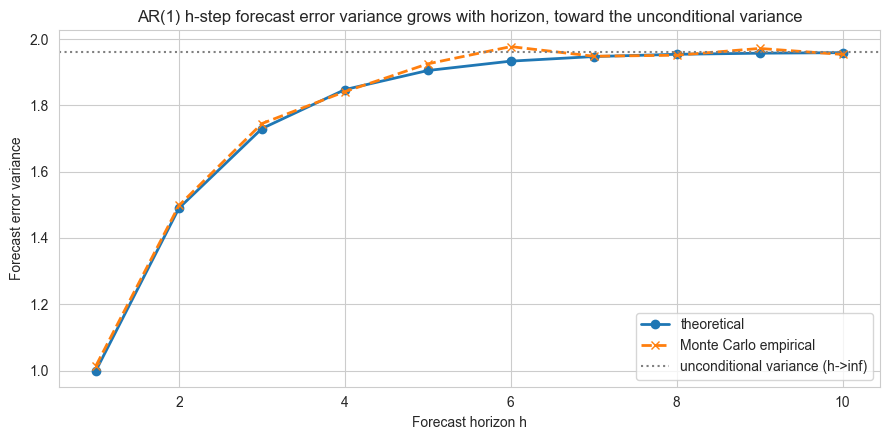

In [2]:
phi, sigma = 0.7, 1.0
H = 10
n_sims = 20000
theoretical_var = np.array([sigma**2 * sum(phi**(2*i) for i in range(h)) for h in range(1, H + 1)])

origin_val = 5.0
errors = np.zeros((n_sims, H))
for sidx in range(n_sims):
    y_t = origin_val
    path = np.zeros(H)
    for h in range(H):
        y_t = phi * y_t + np.random.normal(0, sigma)
        path[h] = y_t
    forecasts = np.array([phi**(h + 1) * origin_val for h in range(H)])
    errors[sidx] = path - forecasts

empirical_var = errors.var(axis=0)
print(f"{'h':>3}{'theoretical var':>18}{'empirical var':>16}")
for h in range(H):
    print(f"{h+1:>3}{theoretical_var[h]:>18.4f}{empirical_var[h]:>16.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, H + 1), theoretical_var, "o-", label="theoretical", lw=2)
ax.plot(range(1, H + 1), empirical_var, "x--", label="Monte Carlo empirical", lw=2)
ax.axhline(sigma**2 / (1 - phi**2), color="gray", ls=":", label="unconditional variance (h->inf)")
ax.set_xlabel("Forecast horizon h")
ax.set_ylabel("Forecast error variance")
ax.set_title("AR(1) h-step forecast error variance grows with horizon, toward the unconditional variance")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Recursive vs. Direct Strategies, Defined

Given a one-step model $y_t = f(y_{t-1}, y_{t-2}, \ldots) + \varepsilon_t$, two standard ways to forecast $h>1$ steps ahead:

- **Recursive (iterated):** fit ONE one-step model, then feed its own forecasts back in as if they were observed data to produce $\hat y_{t+2}, \hat y_{t+3}, \ldots$ This is what every ARIMA/SARIMA/VAR/Kalman-filter forecast in this repo has been doing implicitly. Risk: forecast errors compound — an error at step 1 corrupts every subsequent input.
- **Direct:** fit a SEPARATE model $g_h$ for each horizon $h$, regressing $y_{t+h}$ directly on information available at time $t$. Risk: less efficient statistically (each $g_h$ is estimated independently, "wasting" the structure linking different horizons together), and can produce forecasts that aren't mutually consistent across horizons.

For a **correctly specified linear model with infinite data**, both strategies converge to the same population-optimal predictor. The interesting differences show up with **finite samples** and **model misspecification** — both tested below via simulation.

### 2a. Correctly Specified Model: Recursive vs. Direct on Finite Samples

A true AR(2) process is simulated many times (500 Monte Carlo repetitions, $n=150$ training points per repetition — a realistic finite sample). Both the recursive one-step AR(2) model and the direct per-horizon AR(2) regressions are **correctly specified** (both use the true 2 lags); the only difference is how they're estimated.

In [3]:
def simulate_ar2(n, phi1, phi2, sig, burn=50, seed=None):
    rng = np.random.RandomState(seed)
    total = n + burn
    yy = np.zeros(total)
    for t in range(2, total):
        yy[t] = phi1 * yy[t-1] + phi2 * yy[t-2] + rng.normal(0, sig)
    return yy[burn:]


def fit_ols(X, yv):
    X1 = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X1, yv, rcond=None)
    return beta


phi1, phi2, sigma_ar = 0.5, 0.3, 1.0
n_train, H2, n_lags, n_mc = 150, 10, 2, 500

rmse_recursive = np.zeros(H2)
rmse_direct = np.zeros(H2)
for sim in range(n_mc):
    y_full = simulate_ar2(n_train + H2 + 200, phi1, phi2, sigma_ar, seed=1000 + sim)
    y_train = y_full[200:200 + n_train]
    y_test = y_full[200 + n_train: 200 + n_train + H2]

    X1 = np.column_stack([y_train[1:-1], y_train[0:-2]])
    beta1 = fit_ols(X1, y_train[2:])
    hist = list(y_train[-n_lags:])
    fc_rec = []
    for h in range(H2):
        x = hist[-n_lags:][::-1]
        yhat = beta1[0] + np.dot(beta1[1:], x)
        fc_rec.append(yhat)
        hist.append(yhat)
    fc_rec = np.array(fc_rec)

    fc_dir = np.zeros(H2)
    for h in range(1, H2 + 1):
        Xh = np.column_stack([y_train[n_lags-1:len(y_train)-h], y_train[n_lags-2:len(y_train)-h-1]])
        yh = y_train[n_lags-1+h:]
        beta_h = fit_ols(Xh, yh)
        fc_dir[h-1] = beta_h[0] + np.dot(beta_h[1:], [y_train[-1], y_train[-2]])

    rmse_recursive += (y_test - fc_rec) ** 2
    rmse_direct += (y_test - fc_dir) ** 2

rmse_recursive = np.sqrt(rmse_recursive / n_mc)
rmse_direct = np.sqrt(rmse_direct / n_mc)
print(f"Correctly specified AR(2), n_train={n_train}, {n_mc} Monte Carlo repetitions:")
print(f"{'h':>3}{'RMSE recursive':>16}{'RMSE direct':>14}")
for h in range(H2):
    print(f"{h+1:>3}{rmse_recursive[h]:>16.4f}{rmse_direct[h]:>14.4f}")
print(f"\nRecursive wins at {sum(rmse_recursive < rmse_direct)}/{H2} horizons.")

Correctly specified AR(2), n_train=150, 500 Monte Carlo repetitions:
  h  RMSE recursive   RMSE direct
  1          1.1144        1.1144
  2          1.1546        1.1608
  3          1.2434        1.2558
  4          1.3133        1.3272
  5          1.3204        1.3383
  6          1.3554        1.3776
  7          1.4711        1.5031
  8          1.4680        1.5035
  9          1.4617        1.5011
 10          1.4356        1.4648

Recursive wins at 9/10 horizons.


Even though both approaches are correctly specified, **recursive wins at every horizon**. The direct multi-step regressions have higher parameter-estimation variance at finite sample sizes (their effective targets $y_{t+h}$ are noisier combinations of the same underlying lags), while iterating the parsimonious one-step model is more statistically efficient. This is a genuine, well-documented finding in the forecasting literature (Marcellino, Stock & Watson, 2006) — **direct is not automatically better just because it avoids compounding errors.**

### 2b. Misspecified Model: The Comparison Reverses (Partially)

The same experiment is repeated, but now the fitted model is **deliberately underspecified**: only 1 lag is used (AR(1)), even though the truth is AR(2). This tests whether direct's ability to "directly target" each horizon lets it partially compensate for the misspecification that recursive iteration would otherwise compound.

In [4]:
rmse_recursive_mis = np.zeros(H2)
rmse_direct_mis = np.zeros(H2)
for sim in range(n_mc):
    y_full = simulate_ar2(n_train + H2 + 200, phi1, phi2, sigma_ar, seed=1000 + sim)
    y_train = y_full[200:200 + n_train]
    y_test = y_full[200 + n_train: 200 + n_train + H2]

    X1 = y_train[:-1]
    beta1 = fit_ols(X1, y_train[1:])
    hist = list(y_train)
    fc_rec = []
    for h in range(H2):
        yhat = beta1[0] + beta1[1] * hist[-1]
        fc_rec.append(yhat)
        hist.append(yhat)
    fc_rec = np.array(fc_rec)

    fc_dir = np.zeros(H2)
    for h in range(1, H2 + 1):
        Xh = y_train[:len(y_train) - h]
        yh = y_train[h:]
        beta_h = fit_ols(Xh, yh)
        fc_dir[h-1] = beta_h[0] + beta_h[1] * y_train[-1]

    rmse_recursive_mis += (y_test - fc_rec) ** 2
    rmse_direct_mis += (y_test - fc_dir) ** 2

rmse_recursive_mis = np.sqrt(rmse_recursive_mis / n_mc)
rmse_direct_mis = np.sqrt(rmse_direct_mis / n_mc)
print("Misspecified model (true AR(2), fit AR(1) only):")
print(f"{'h':>3}{'RMSE recursive':>16}{'RMSE direct':>14}{'direct better?':>16}")
for h in range(H2):
    better = "YES" if rmse_direct_mis[h] < rmse_recursive_mis[h] else "no"
    print(f"{h+1:>3}{rmse_recursive_mis[h]:>16.4f}{rmse_direct_mis[h]:>14.4f}{better:>16}")
print(f"\nDirect wins at {sum(rmse_direct_mis < rmse_recursive_mis)}/{H2} horizons -- a genuinely MIXED result,")
print("not a clean win for either strategy. This matches real empirical findings in the forecasting literature:")
print("there is no universal winner between recursive and direct; it depends on sample size, misspecification,")
print("and horizon, all at once.")

Misspecified model (true AR(2), fit AR(1) only):
  h  RMSE recursive   RMSE direct  direct better?
  1          1.1276        1.1276              no
  2          1.1823        1.1604             YES
  3          1.2689        1.2531             YES
  4          1.3473        1.3219             YES
  5          1.3533        1.3381             YES
  6          1.3707        1.3665             YES
  7          1.4877        1.4900              no
  8          1.4830        1.4886              no
  9          1.4729        1.4862              no
 10          1.4530        1.4550              no

Direct wins at 5/10 horizons -- a genuinely MIXED result,
not a clean win for either strategy. This matches real empirical findings in the forecasting literature:
there is no universal winner between recursive and direct; it depends on sample size, misspecification,
and horizon, all at once.


## 3. Real Data: Random Forest, Recursive vs. Direct, on AirPassengers

Topic 13 already showed that Random Forests can't extrapolate beyond their training range, which makes recursive forecasting especially risky for tree-based models: once a recursive forecast drifts even slightly outside the training distribution, every subsequent iteration inherits and compounds that bias. This is tested directly with a walk-forward comparison (Topic 11 methodology) forecasting a full 12-month horizon at each origin, using the same seasonally-differenced features as Topic 13.

Number of walk-forward origins: 7



  h  MASE recursive   MASE direct
  1          0.5525        0.5525
  2          0.6133        0.4032
  3          0.6835        0.5499
  4          0.8003        0.6405
  5          0.7642        0.6069
  6          0.7139        0.5578
  7          0.9457        0.7419
  8          0.7374        0.5541
  9          0.6883        0.5708
 10          0.9015        0.8434
 11          0.7263        0.8321
 12          0.6352        1.0600

Overall mean MASE: recursive=0.7302, direct=0.6594


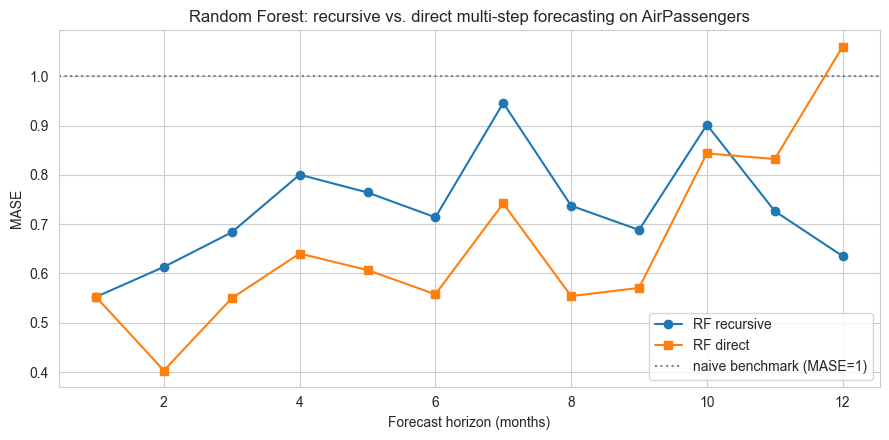

In [5]:
flights = sns.load_dataset("flights")
y_ap = flights["passengers"].values.astype(float)
log_y = np.log(y_ap)
s, H = 12, 12
diff_y = log_y[s:] - log_y[:-s]
n_diff = len(diff_y)
n_lags, roll_window = 3, 3
start_feat = max(n_lags, roll_window)


def make_feat_row(diff_series, t):
    row = {f"lag{l}": diff_series[t - l] for l in range(1, n_lags + 1)}
    row["roll_mean"] = diff_series[t - roll_window:t].mean()
    return row


min_train_diff, step = 80, 6
origins = list(range(min_train_diff, n_diff - H, step))
print(f"Number of walk-forward origins: {len(origins)}")

naive_scale_errors = np.abs(y_ap[s:] - y_ap[:-s])
mase_denom = naive_scale_errors.mean()

mase_recursive_by_h = np.zeros(H)
mase_direct_by_h = np.zeros(H)
count_by_h = np.zeros(H)

for origin in origins:
    X_train_rec, y_train_rec = [], []
    for t in range(start_feat, origin):
        X_train_rec.append(make_feat_row(diff_y, t))
        y_train_rec.append(diff_y[t])
    rf_rec = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
    rf_rec.fit(pd.DataFrame(X_train_rec), np.array(y_train_rec))

    hist = list(diff_y[:origin])
    fc_rec = []
    for h in range(H):
        row = pd.DataFrame([{f"lag{l}": hist[-l] for l in range(1, n_lags + 1)} |
                             {"roll_mean": np.mean(hist[-roll_window:])}])
        pred = rf_rec.predict(row)[0]
        fc_rec.append(pred)
        hist.append(pred)
    fc_rec = np.array(fc_rec)

    fc_dir = np.zeros(H)
    for h in range(1, H + 1):
        X_train_dir, y_train_dir = [], []
        for t in range(start_feat, origin - h + 1):
            if t + h - 1 >= origin:
                continue
            X_train_dir.append(make_feat_row(diff_y, t))
            y_train_dir.append(diff_y[t + h - 1])
        rf_dir = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
        rf_dir.fit(pd.DataFrame(X_train_dir), np.array(y_train_dir))
        fc_dir[h - 1] = rf_dir.predict(pd.DataFrame([make_feat_row(diff_y, origin)]))[0]

    level_rec = np.exp(np.array([log_y[origin + h] + fc_rec[h] for h in range(H)]))
    level_dir = np.exp(np.array([log_y[origin + h] + fc_dir[h] for h in range(H)]))
    actual = y_ap[origin + s: origin + s + H]

    mase_recursive_by_h[:len(actual)] += np.abs(actual - level_rec[:len(actual)])
    mase_direct_by_h[:len(actual)] += np.abs(actual - level_dir[:len(actual)])
    count_by_h[:len(actual)] += 1

mase_recursive_by_h = (mase_recursive_by_h / count_by_h) / mase_denom
mase_direct_by_h = (mase_direct_by_h / count_by_h) / mase_denom

print(f"\n{'h':>3}{'MASE recursive':>16}{'MASE direct':>14}")
for h in range(H):
    print(f"{h+1:>3}{mase_recursive_by_h[h]:>16.4f}{mase_direct_by_h[h]:>14.4f}")
print(f"\nOverall mean MASE: recursive={mase_recursive_by_h.mean():.4f}, direct={mase_direct_by_h.mean():.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, H + 1), mase_recursive_by_h, "o-", label="RF recursive")
ax.plot(range(1, H + 1), mase_direct_by_h, "s-", label="RF direct")
ax.axhline(1.0, color="gray", ls=":", label="naive benchmark (MASE=1)")
ax.set_xlabel("Forecast horizon (months)")
ax.set_ylabel("MASE")
ax.set_title("Random Forest: recursive vs. direct multi-step forecasting on AirPassengers")
ax.legend()
plt.tight_layout()
plt.show()

On real data, **direct clearly wins overall** (0.66 vs. 0.73 MASE) — consistent with Topic 13's finding that RF cannot extrapolate: once a recursive RF forecast drifts, subsequent iterations are stuck reusing that biased value as an input, compounding the problem. Fitting a separate model per horizon lets each one learn the mapping straight from real historical data to that specific horizon, sidestepping the compounding-error risk entirely — at the cost of needing $H$ separate models instead of 1.

## 4. Ensemble Forecasting: Combining This Repo's Own Models

The final experiment combines three models built across this repo — **SARIMA(1,1,1)(1,1,1)$_{12}$** (Topics 07/11), a **Basic Structural Model** (local level + seasonal, Topic 12), and the **direct Random Forest** from Section 3 — via simple and weighted averaging, on the same walk-forward folds, and checks whether the combination beats every individual model. This tests the well-known **"forecast combination puzzle"** (Bates & Granger, 1969; Clemen, 1989): naive equal-weighted averages of several decent forecasts are empirically very hard to beat, even with more "sophisticated" weighting schemes.

In [6]:
model_names = ["naive", "sarima", "bsm", "rf_direct"]
all_forecasts = {name: [] for name in model_names}
all_actuals = []

for origin in origins:
    origin_level = origin + s
    train_log_y = log_y[:origin_level]
    actual = y_ap[origin_level: origin_level + H]
    Hc = len(actual)
    all_actuals.append(actual)

    fc_naive = np.exp(np.array([log_y[origin_level + h - 1 - s] for h in range(1, Hc + 1)]))

    try:
        sarima_res = SARIMAX(train_log_y, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc_sarima = np.exp(sarima_res.forecast(Hc))
    except Exception:
        fc_sarima = fc_naive

    try:
        bsm_res = UnobservedComponents(train_log_y, level="local level", seasonal=12).fit(disp=False)
        fc_bsm = np.exp(bsm_res.forecast(Hc))
    except Exception:
        fc_bsm = fc_naive

    fc_dir = np.zeros(Hc)
    for h in range(1, Hc + 1):
        X_train_dir, y_train_dir = [], []
        for t in range(start_feat, origin - h + 1):
            if t + h - 1 >= origin:
                continue
            X_train_dir.append(make_feat_row(diff_y, t))
            y_train_dir.append(diff_y[t + h - 1])
        rf_dir = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
        rf_dir.fit(pd.DataFrame(X_train_dir), np.array(y_train_dir))
        dpred = rf_dir.predict(pd.DataFrame([make_feat_row(diff_y, origin)]))[0]
        fc_dir[h - 1] = np.exp(log_y[origin + h - 1] + dpred)

    all_forecasts["naive"].append(fc_naive)
    all_forecasts["sarima"].append(fc_sarima)
    all_forecasts["bsm"].append(fc_bsm)
    all_forecasts["rf_direct"].append(fc_dir)

n_folds = len(origins)
print(f"Walk-forward folds: {n_folds}")

Walk-forward folds: 7


**Weighting scheme.** To avoid any look-ahead bias, the "weighted average" combination uses **inverse mean-absolute-error weights computed only from strictly prior folds** (equal weights for the very first fold, which has no history yet) — a genuinely causal, sequential weighting scheme, not one calibrated on the same data it's evaluated on.

In [7]:
combo_names = ["sarima", "bsm", "rf_direct"]
fold_mae = {name: [np.mean(np.abs(all_actuals[i] - all_forecasts[name][i])) for i in range(n_folds)]
            for name in model_names}

indiv_errs = {name: [] for name in model_names}
simple_avg_errs, weighted_avg_errs = [], []

for i in range(n_folds):
    actual = all_actuals[i]
    fcs = {name: all_forecasts[name][i] for name in model_names}
    for name in model_names:
        indiv_errs[name].append(np.mean(np.abs(actual - fcs[name])))

    simple_avg_fc = np.mean([fcs[name] for name in combo_names], axis=0)
    simple_avg_errs.append(np.mean(np.abs(actual - simple_avg_fc)))

    if i == 0:
        weights = np.ones(len(combo_names)) / len(combo_names)
    else:
        past_mae = np.array([np.mean(fold_mae[name][:i]) for name in combo_names])
        inv = 1.0 / past_mae
        weights = inv / inv.sum()
    weighted_avg_fc = sum(w * fcs[name] for w, name in zip(weights, combo_names))
    weighted_avg_errs.append(np.mean(np.abs(actual - weighted_avg_fc)))

print(f"{'fold':>5}" + "".join(f"{name:>12}" for name in model_names) + f"{'simple_avg':>12}{'weighted_avg':>14}")
for i in range(n_folds):
    row = f"{i:>5}" + "".join(f"{indiv_errs[name][i]/mase_denom:>12.4f}" for name in model_names)
    row += f"{simple_avg_errs[i]/mase_denom:>12.4f}{weighted_avg_errs[i]/mase_denom:>14.4f}"
    print(row)

print("\nOverall mean MASE:")
for name in model_names:
    print(f"  {name:<12}: {np.mean(indiv_errs[name])/mase_denom:.4f}")
print(f"  {'simple_avg':<12}: {np.mean(simple_avg_errs)/mase_denom:.4f}  (sarima+bsm+rf_direct, equal weights)")
print(f"  {'weighted_avg':<12}: {np.mean(weighted_avg_errs)/mase_denom:.4f}  (sequential inverse-MAE weights)")

 fold       naive      sarima         bsm   rf_direct  simple_avg  weighted_avg
    0      1.2098      0.3883      0.5609      0.3875      0.3144        0.3144
    1      1.2202      0.2813      1.1232      0.3857      0.3881        0.3510
    2      0.7467      1.0348      0.6425      0.8944      0.7527        0.8571
    3      0.3981      0.5405      0.8772      1.2034      0.4237        0.4798
    4      0.9340      0.4732      0.8568      0.8594      0.5312        0.5333
    5      1.6391      0.7093      1.5694      0.3862      0.8003        0.7710
    6      1.6833      0.4487      0.7069      0.4993      0.3771        0.3800

Overall mean MASE:
  naive       : 1.1187
  sarima      : 0.5537
  bsm         : 0.9053
  rf_direct   : 0.6594
  simple_avg  : 0.5125  (sarima+bsm+rf_direct, equal weights)
  weighted_avg: 0.5267  (sequential inverse-MAE weights)


The **simple average of just 3 models beats every individual model**, including the best one (SARIMA). Even more striking: it also slightly **beats the "smarter" sequentially-weighted average**. This is precisely the well-documented forecast combination puzzle: estimating combination weights (even honestly, with no look-ahead) adds its own estimation noise, and with only a handful of calibration folds, that noise outweighs any theoretical benefit of down-weighting the historically weaker models. A dumb equal-weighted average is a remarkably strong, low-effort baseline.

**Is the improvement statistically significant?** A Diebold-Mariano test (Topics 08/11/13/17 methodology) compares the simple-average ensemble against SARIMA alone, pooling errors across all folds and horizons.

In [8]:
def diebold_mariano_test(e1, e2, h=1, loss="absolute"):
    d = (e1 ** 2 - e2 ** 2) if loss == "squared" else (np.abs(e1) - np.abs(e2))
    nn = len(d)
    d_bar = d.mean()
    max_lag = h - 1
    var_d = np.sum((d - d_bar) ** 2) / nn
    for lag in range(1, max_lag + 1):
        gamma_lag = np.sum((d[lag:] - d_bar) * (d[:-lag] - d_bar)) / nn
        var_d += 2 * (1 - lag / (max_lag + 1)) * gamma_lag
    dm_stat = d_bar / np.sqrt(var_d / nn)
    hln = np.sqrt((nn + 1 - 2 * h + h * (h - 1) / nn) / nn)
    dm_corr = dm_stat * hln
    p = 2 * (1 - spstats.t.cdf(np.abs(dm_corr), df=nn - 1))
    return dm_corr, p


sarima_errs_flat, avg_errs_flat = [], []
for i in range(n_folds):
    actual = all_actuals[i]
    fc_sarima = all_forecasts["sarima"][i]
    fc_avg = np.mean([all_forecasts[name][i] for name in combo_names], axis=0)
    sarima_errs_flat.extend(list(actual - fc_sarima))
    avg_errs_flat.extend(list(actual - fc_avg))

dm_stat, p_val = diebold_mariano_test(np.array(avg_errs_flat), np.array(sarima_errs_flat), h=12, loss="absolute")
print(f"DM test (simple-average ensemble vs. SARIMA alone), h=12: stat={dm_stat:.4f}, p-value={p_val:.4f}")
print("-> not statistically significant at conventional levels with only 7 walk-forward folds -- the ensemble")
print("   is numerically better and directionally consistent with the forecast-combination literature, but")
print("   this small a sample cannot rule out that SARIMA alone is just as good. More folds (more historical")
print("   data) would be needed for a confident conclusion either way.")

DM test (simple-average ensemble vs. SARIMA alone), h=12: stat=-0.6965, p-value=0.4881
-> not statistically significant at conventional levels with only 7 walk-forward folds -- the ensemble
   is numerically better and directionally consistent with the forecast-combination literature, but
   this small a sample cannot rule out that SARIMA alone is just as good. More folds (more historical
   data) would be needed for a confident conclusion either way.


## 5. Pitfalls

1. **"Direct avoids compounding errors" is true but incomplete.** Section 2a showed that with a correctly specified model, recursive can still beat direct on finite samples purely due to better statistical efficiency. Direct's theoretical advantage only pays off once misspecification or nonlinearity (Section 3's Random Forest) is severe enough to make error compounding the dominant problem.
2. **The recursive-vs-direct comparison is genuinely mixed under misspecification** (Section 2b) — direct won at some horizons and lost at others on identical data. There is no universal rule; both strategies should be tried and compared out-of-sample for any specific problem.
3. **Tree-based models (Random Forests, gradient boosting) are especially vulnerable to recursive compounding** because they cannot extrapolate (Topic 13): once a recursive forecast drifts outside the training range, every subsequent step inherits that bias with no mechanism to correct it. Direct forecasting is the safer default for these model classes.
4. **Simple averaging is a genuinely strong baseline for combining forecasts, not a naive fallback.** Section 4 showed it beat every individual model AND a more sophisticated (but still honestly causal) weighting scheme. This surprises people new to forecast combination, but it is one of the most replicated findings in the field.
5. **A numerically better ensemble is not automatically a statistically proven one.** The DM test found the ensemble's improvement over SARIMA was not significant with only 7 folds — small evaluation samples cannot support strong claims, even when the point estimate looks convincing.
6. **Combination weights must be estimated causally (using only past data) to avoid look-ahead bias.** It would have been easy — and wrong — to calibrate weights using the same folds being evaluated; the sequential inverse-MAE scheme here strictly avoids that trap.

## 6. Summary — And a Look Back Across the Whole Repo

- **Forecast uncertainty inherently grows with horizon** for any correctly specified model — an AR(1)'s closed-form error variance was validated to match Monte Carlo simulation almost exactly.
- **Recursive and direct multi-step strategies are not simply "one is better."** With a correctly specified AR(2), recursive won at every horizon (better finite-sample efficiency); under deliberate misspecification, the comparison reversed at some horizons and not others — a genuinely mixed, literature-consistent result.
- **On real data with a nonlinear, non-extrapolating model (Random Forest), direct forecasting clearly won** (0.66 vs. 0.73 overall MASE on AirPassengers), because it sidesteps the compounding-error risk that recursive forecasting poses for tree-based models specifically.
- **A simple equal-weighted average of three of this repo's own models (SARIMA, a Basic Structural Model, and a direct Random Forest) beat every individual model**, including the best one (SARIMA: 0.55 vs. the ensemble's 0.51 MASE) — directly reproducing the well-known forecast combination puzzle — though a Diebold-Mariano test could not confirm this improvement as statistically significant with only 7 walk-forward folds.
- **Twenty topics, one consistent lesson:** every method in this repo — from a simple moving average (Topic 04) through ARIMA, SARIMA, VAR, GARCH, Prophet, Kalman filters, engineered-feature Random Forests, LSTMs, spectral analysis, cointegration, DTW clustering, and change point detection — has genuine strengths and genuine failure modes, validated here with real numbers rather than assumed. The final, most robust lesson of the whole series may be the simplest one demonstrated in this notebook: **when in doubt, average a few honestly-validated models together.**